In [21]:
import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
import os

# Load

In [22]:
path = "data/fluxnet_div_ross.nc"

with xr.open_dataset(path) as _ds:
    ds = _ds.load()

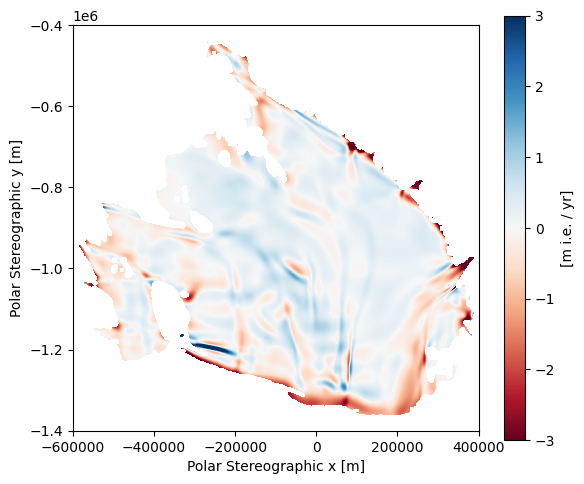

In [23]:
plt.figure(figsize = (6, 5))

X, Y = xr.broadcast(ds.x, ds.y)

pcm = plt.pcolormesh(
    X,
    Y,
    ds.fluxnet_div.values,
    cmap = "RdBu",
    vmin = -3.0,
    vmax = 3.0,  
)

plt.colorbar(pcm, label = "[m i.e. / yr]")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Show with altimetry grid

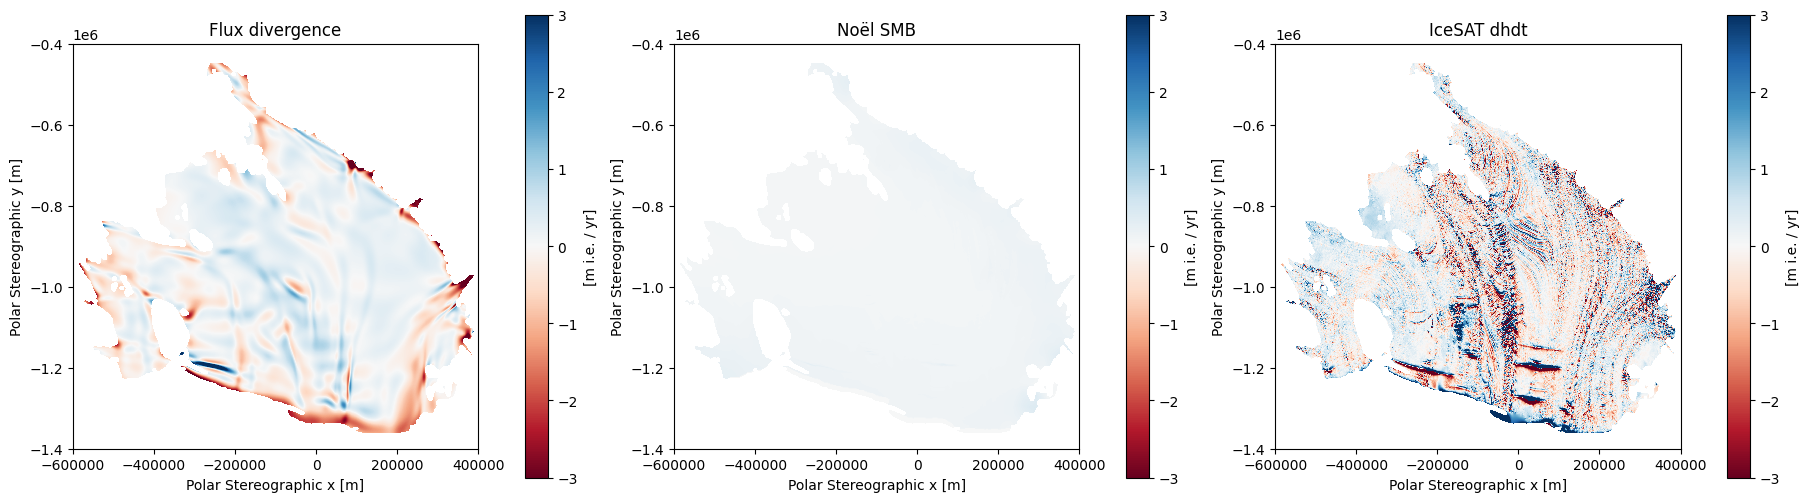

In [24]:
# 2D grids for pcolormesh
X, Y = xr.broadcast(ds.x, ds.y)

fig, axes = plt.subplots(1, 3, figsize = (18, 5), constrained_layout = True)

fields = [
    ("fluxnet_div", ds.fluxnet_div, "Flux divergence"),
    # NOTE: need to transpose noel_smb to match grid orientation
    ("noel_smb", ds.noel_smb, "Noël SMB"),
    ("IceSat dhdt", ds.icesat_dhdt, "IceSAT dhdt"),
]

for ax, (_, da, title) in zip(axes, fields):
    pcm = ax.pcolormesh(
        X, Y,
        da.values,
        cmap = "RdBu",
        vmin = -3.0,
        vmax = 3.0,
        shading = "auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Polar Stereographic x [m]")
    ax.set_ylabel("Polar Stereographic y [m]")
    ax.set_aspect("equal")
    fig.colorbar(pcm, ax = ax, label = "[m i.e. / yr]")

plt.show()

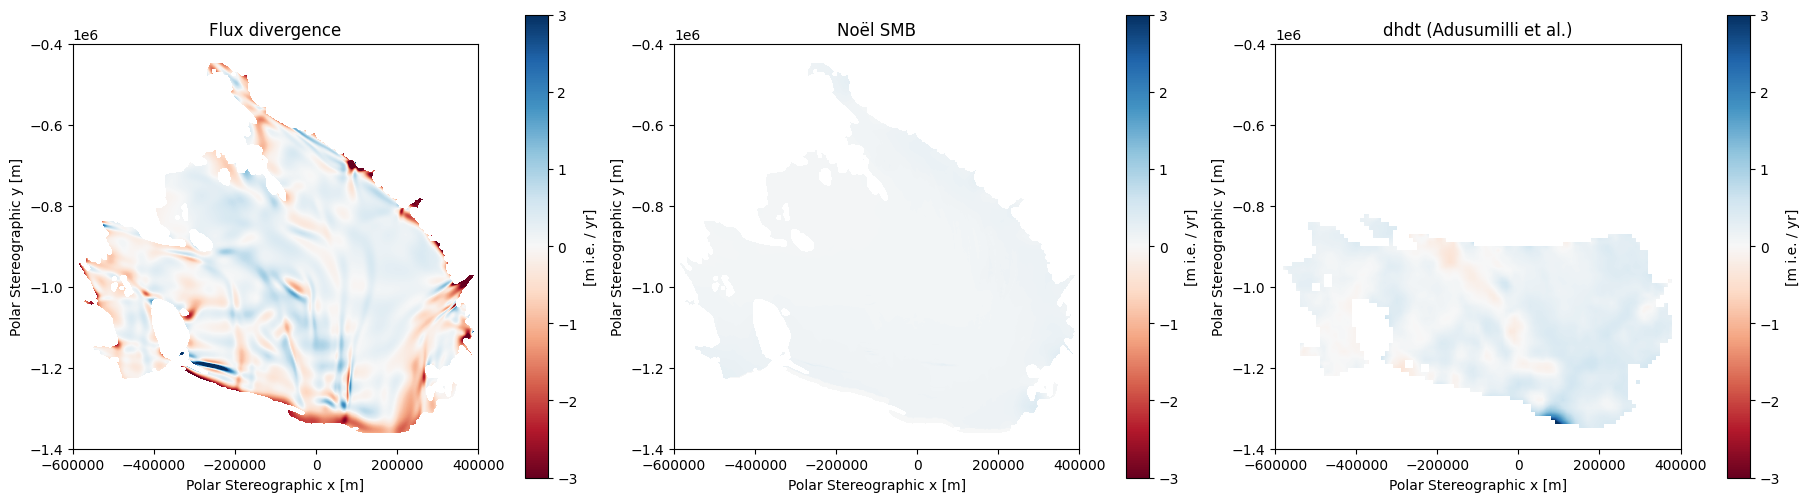

In [25]:
# 2D grids for pcolormesh
X, Y = xr.broadcast(ds.x, ds.y)

fig, axes = plt.subplots(1, 3, figsize = (18, 5), constrained_layout = True)

fields = [
    ("fluxnet_div", ds.fluxnet_div, "Flux divergence"),
    # NOTE: need to transpose noel_smb to match grid orientation
    ("noel_smb",    ds.noel_smb,  "Noël SMB"),
    ("adusumilli_dhdt", ds.adusumilli_dhdt, "dhdt (Adusumilli et al.)"),
]

for ax, (_, da, title) in zip(axes, fields):
    pcm = ax.pcolormesh(
        X, Y,
        da.values,
        cmap = "RdBu",
        vmin = -3.0,
        vmax = 3.0,
        shading = "auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Polar Stereographic x [m]")
    ax.set_ylabel("Polar Stereographic y [m]")
    ax.set_aspect("equal")
    fig.colorbar(pcm, ax = ax, label = "[m i.e. / yr]")

plt.show()

# Construct

In [26]:
fluxnet_bmb = ds.fluxnet_div.values - ds.noel_smb.values + ds.icesat_dhdt.values

# Fill in dhdt Adusumilli et al. with zeroes where missing
# Work in the transposed view you referenced
ad = ds["adusumilli_dhdt"].values              # shape (x, y)
flux = ds["fluxnet_div"].values                # shape (x, y)

# Where fluxnet_div has data (not-NaN) but adusumilli_dhdt is NaN -> set to 0
ad[np.isnan(ad) & ~ np.isnan(flux)] = 0.0
# Write back to ds in original (y, x) orientation
ds["adusumilli_dhdt"] = (("y", "x"), ad)
fluxnet_bmb_adsu = ds.fluxnet_div.values - ds.noel_smb.values + ds.adusumilli_dhdt.values

# IceSat 2 data is too noisy

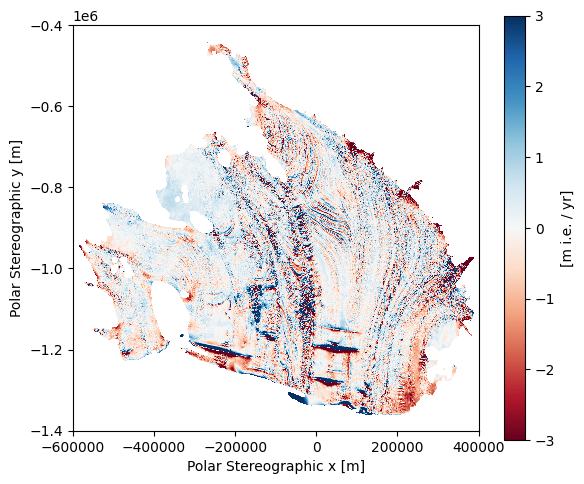

In [27]:
plt.figure(figsize = (6, 5))

pcm = plt.pcolormesh(
    X,
    Y,
    fluxnet_bmb,
    cmap = "RdBu",
    vmin = -3.0,
    vmax = 3.0,  
)

plt.colorbar(pcm, label = "[m i.e. / yr]")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

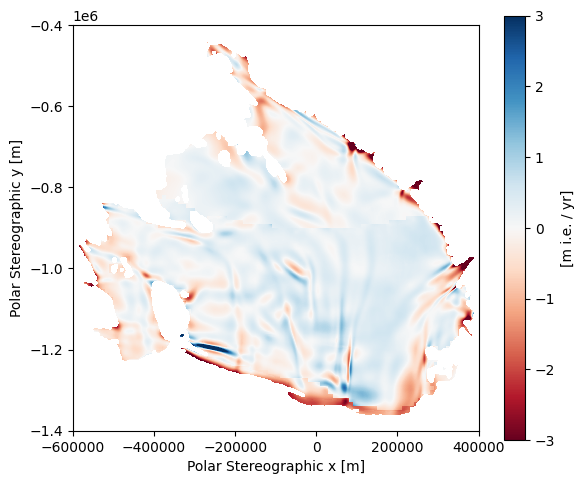

In [28]:
plt.figure(figsize = (6, 5))

pcm = plt.pcolormesh(
    X,
    Y,
    fluxnet_bmb_adsu,
    cmap = "RdBu",
    vmin = -3.0,
    vmax = 3.0,  
)

plt.colorbar(pcm, label = "[m i.e. / yr]")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

In [29]:
fluxnet_bmb

print("smb range")
print(np.nanmin(ds.noel_smb), np.nanmax(ds.noel_smb))
print("")
print("fluxnet div range")
print(np.nanmin(ds.fluxnet_div), np.nanmax(ds.fluxnet_div))
print("")
print("icesat dhdt range")
print(np.nanmin(ds.icesat_dhdt), np.nanmax(ds.icesat_dhdt))

smb range
0.0 0.42398614

fluxnet div range
-21.06171 7.629963

icesat dhdt range
-80.21221227044462 62.036267439524366


In [30]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

In [31]:
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

X, Y = xr.broadcast(target_grid_mask.x, target_grid_mask.y)

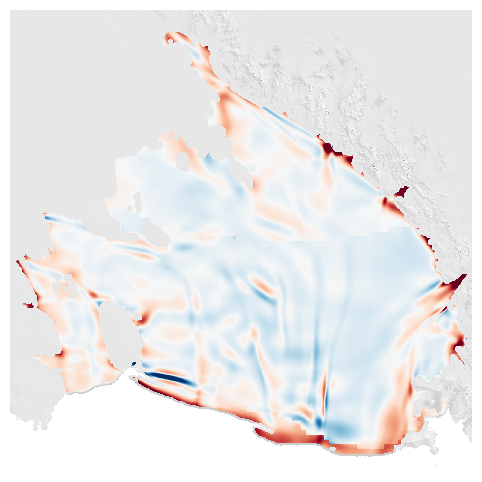

In [32]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    X.values,
    Y.values,
    # mm -> m
    fluxnet_bmb_adsu,
    cmap = "RdBu",
    vmin = -3,
    vmax = 3,
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/fluxnet_bmb_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

# Show difference

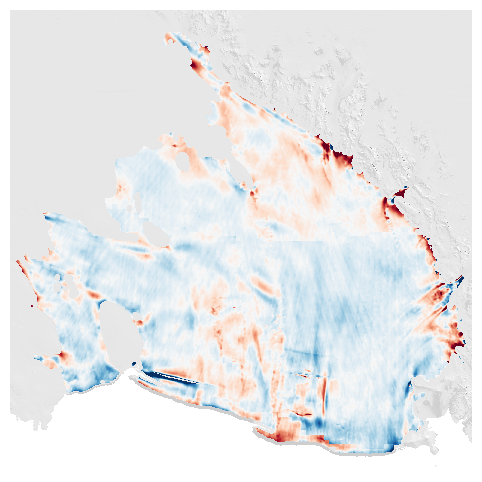

In [33]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
pcm = ax.pcolormesh(
    X.values,
    Y.values,
    # mm -> m
    fluxnet_bmb_adsu - ds.adusumilli_bmb.values,
    cmap = "RdBu",
    vmin = -3,
    vmax = 3,
    alpha = 1.0,
    zorder = 1,
)

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/fluxnet_adsu_difference_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()